#### Import the libraries 

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

import warnings
warnings.filterwarnings("ignore")

#### Load the dataset and add headers

In [2]:
movies = pd.read_csv("movies.csv")
ratings = pd.read_csv("ratings.csv")

In [3]:
print("Movies Shape :", movies.shape)
print("Ratings Shape :", ratings.shape)

Movies Shape : (9742, 3)
Ratings Shape : (100836, 4)


In [4]:
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [5]:
ratings.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


#### Missing Values

In [6]:
movies.isnull().sum()

movieId    0
title      0
genres     0
dtype: int64

In [7]:
ratings.isnull().sum()

userId       0
movieId      0
rating       0
timestamp    0
dtype: int64

#### Duplicate Values

In [8]:
movies.duplicated().sum()

np.int64(0)

In [9]:
ratings.duplicated().sum()

np.int64(0)

#### Data Information

In [10]:
movies.info()

<class 'pandas.DataFrame'>
RangeIndex: 9742 entries, 0 to 9741
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   movieId  9742 non-null   int64
 1   title    9742 non-null   str  
 2   genres   9742 non-null   str  
dtypes: int64(1), str(2)
memory usage: 228.5 KB


In [11]:
ratings.info()

<class 'pandas.DataFrame'>
RangeIndex: 100836 entries, 0 to 100835
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     100836 non-null  int64  
 1   movieId    100836 non-null  int64  
 2   rating     100836 non-null  float64
 3   timestamp  100836 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 3.1 MB


#### Genre Distribution

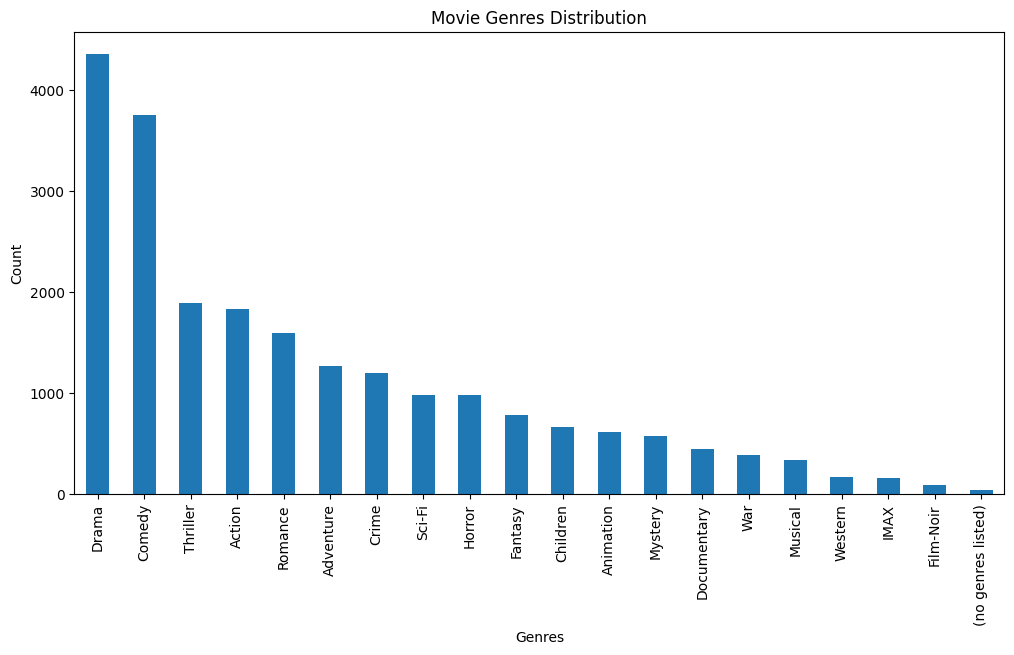

In [12]:
genre_count = movies['genres'].str.get_dummies(sep='|').sum()

plt.figure(figsize=(12,6))
genre_count.sort_values(ascending=False).plot(kind='bar')
plt.title("Movie Genres Distribution")
plt.xlabel("Genres")
plt.ylabel("Count")
plt.show()

#### Rating Distribution

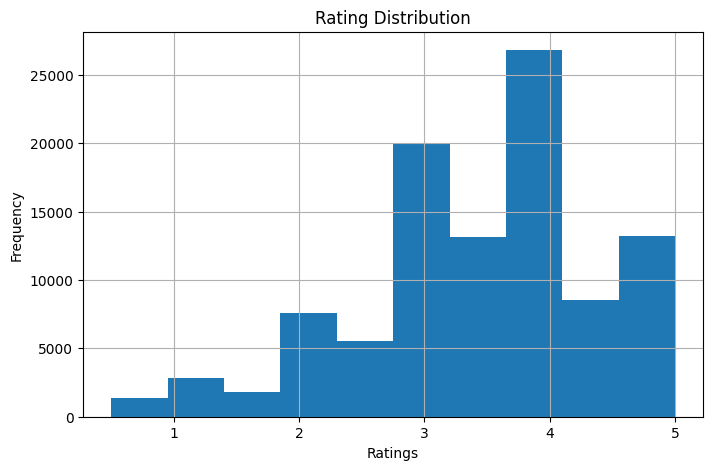

In [13]:
plt.figure(figsize=(8,5))
ratings['rating'].hist(bins=10)
plt.title("Rating Distribution")
plt.xlabel("Ratings")
plt.ylabel("Frequency")
plt.show()

#### Most Rated Movies

In [14]:
movie_ratings = ratings.groupby('movieId').size()

top_movies = movie_ratings.sort_values(ascending=False).head(10)

top_movies = pd.DataFrame(top_movies)

top_movies.reset_index(inplace=True)

top_movies = top_movies.merge(movies,on='movieId')

top_movies

,movieId,0,title,genres
0,356,329,Forrest Gump (1994),Comedy|Drama|Romance|War
1,318,317,"Shawshank Redemption, The (1994)",Crime|Drama
2,296,307,Pulp Fiction (1994),Comedy|Crime|Drama|Thriller
3,593,279,"Silence of the Lambs, The (1991)",Crime|Horror|Thriller
4,2571,278,"Matrix, The (1999)",Action|Sci-Fi|Thriller
5,260,251,Star Wars: Episode IV - A New Hope (1977),Action|Adventure|Sci-Fi
6,480,238,Jurassic Park (1993),Action|Adventure|Sci-Fi|Thriller
7,110,237,Braveheart (1995),Action|Drama|War
8,589,224,Terminator 2: Judgment Day (1991),Action|Sci-Fi
9,527,220,Schindler's List (1993),Drama|War


#### Feature Engineering

In [22]:
movies['genres'] = movies['genres'].str.replace('|',' ',regex=False)

movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure Animation Children Comedy Fantasy
1,2,Jumanji (1995),Adventure Children Fantasy
2,3,Grumpier Old Men (1995),Comedy Romance
3,4,Waiting to Exhale (1995),Comedy Drama Romance
4,5,Father of the Bride Part II (1995),Comedy


#### TF-IDF (Term Frequency - Inverse Document Frequency)

In [16]:
tfidf = TfidfVectorizer(stop_words='english')

tfidf_matrix = tfidf.fit_transform(movies['genres'])

#### Cosine Similarity

In [17]:
cosine_sim = cosine_similarity(tfidf_matrix)

print(cosine_sim.shape)

(9742, 9742)


#### Create Index

In [18]:
indices = pd.Series(movies.index,index=movies['title']).drop_duplicates()

# Recommendation Function

In [19]:
def recommend_movies(title, cosine_sim=cosine_sim):

    idx = indices[title]

    similarity_scores = list(enumerate(cosine_sim[idx]))

    similarity_scores = sorted(
        similarity_scores,
        key=lambda x:x[1],
        reverse=True
    )

    similarity_scores = similarity_scores[1:11]

    movie_indices = [i[0] for i in similarity_scores]

    return movies[['title','genres']].iloc[movie_indices]

In [20]:
recommend_movies("Toy Story (1995)")

,title,genres
1706,Antz (1998),Adventure Animation Children Comedy Fantasy
2355,Toy Story 2 (1999),Adventure Animation Children Comedy Fantasy
2809,"Adventures of Rocky and Bullwinkle, The (2000)",Adventure Animation Children Comedy Fantasy
3000,"Emperor's New Groove, The (2000)",Adventure Animation Children Comedy Fantasy
3568,"Monsters, Inc. (2001)",Adventure Animation Children Comedy Fantasy
6194,"Wild, The (2006)",Adventure Animation Children Comedy Fantasy
6486,Shrek the Third (2007),Adventure Animation Children Comedy Fantasy
6948,"Tale of Despereaux, The (2008)",Adventure Animation Children Comedy Fantasy
7760,Asterix and the Vikings (Astérix et les Viking...,Adventure Animation Children Comedy Fantasy
8219,Turbo (2013),Adventure Animation Children Comedy Fantasy


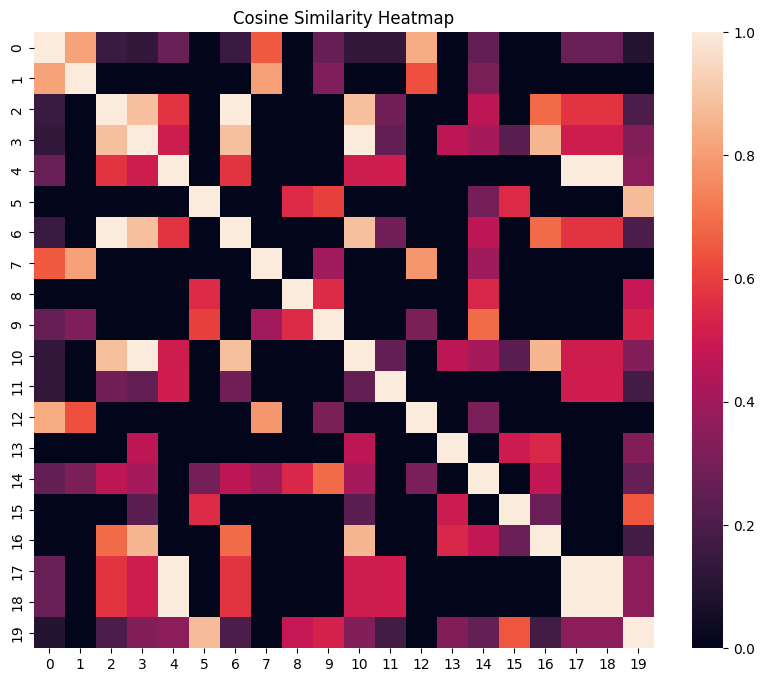

In [21]:
plt.figure(figsize=(10,8))

sns.heatmap(cosine_sim[:20,:20])

plt.title("Cosine Similarity Heatmap")

plt.show()